## Some test data

Download some data set (~120Mb for gamma and ~40Mb for protons)

In [1]:
! mkdir -p gamma
! scp cp03:/fefs/aswg/workspace/ievgen.vovk/lst/allsky-mc-irf/mc/dl2-merged/dec_3476/GammaDiffuse/node_corsika_theta_19.807_az_66.706_/dl2_simtel_corsika_theta_19.807_az_66.706_merged.h5 gamma/

! mkdir -p protons
! scp cp03:/fefs/aswg/workspace/ievgen.vovk/lst/allsky-mc-irf/mc/dl2-merged/dec_3476/Protons/node_corsika_theta_19.807_az_66.706_/dl2_simtel_corsika_theta_19.807_az_66.706_merged.h5 protons/

dl2_simtel_corsika_theta_19.807_az_66.706_mer 100%  117MB   4.6MB/s   00:25    
dl2_simtel_corsika_theta_19.807_az_66.706_mer 100%   43MB   4.5MB/s   00:09    


## Read data and compute reconstruction offset

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot

In [2]:
file_name = "/fefs/aswg/workspace/silvia.garciasoto/EVENT_TYPES/ET_LST/Crab_2023_01_17/dl2_20230127_v0.9.12_base_prod_az_tel_node_theta_52.374_az_49.119__merged.h5"
#file_name = "/fefs/aswg/workspace/silvia.garciasoto/EVENT_TYPES/ET_LST/CrabNebula/dl2_LST-1.Run16069.h5"
data = pd.read_hdf(
    file_name,
    key='dl2/event/telescope/parameters/LST_LSTCam'
)

In [3]:
data.groupby(['obs_id', 'event_id']).size().reset_index(name='counts')

,obs_id,event_id,counts
0,101,1507,1
1,101,1907,1
2,101,2207,1
3,101,2406,1
4,101,2500,1
...,...,...,...
2045490,50001,1997001,1
2045491,50001,1997301,1
2045492,50001,1997302,1
2045493,50001,1998700,1


In [4]:
data.columns

Index(['obs_id', 'event_id', 'intensity', 'log_intensity', 'x', 'y', 'r',
       'phi', 'length', 'length_uncertainty', 'width', 'width_uncertainty',
       'psi', 'skewness', 'kurtosis', 'time_gradient', 'intercept',
       'leakage_intensity_width_1', 'leakage_intensity_width_2',
       'leakage_pixels_width_1', 'leakage_pixels_width_2', 'n_pixels',
       'concentration_cog', 'concentration_core', 'concentration_pixel',
       'n_islands', 'alt_tel', 'az_tel', 'sin_az_tel', 'calibration_id',
       'mc_energy', 'log_mc_energy', 'mc_alt', 'mc_az', 'mc_core_x',
       'mc_core_y', 'mc_h_first_int', 'mc_type', 'mc_az_tel', 'mc_alt_tel',
       'mc_x_max', 'mc_core_distance', 'wl', 'tel_id', 'tel_pos_x',
       'tel_pos_y', 'tel_pos_z', 'trigger_type', 'trigger_time', 'event_type',
       'disp_dx', 'disp_dy', 'disp_norm', 'disp_angle', 'disp_sign', 'src_x',
       'src_y', 'log_reco_energy', 'reco_energy', 'reco_disp_norm',
       'reco_disp_sign', 'reco_disp_dx', 'reco_disp_dy', 'reco

In [6]:
unique_combinations = data.groupby(['obs_id', 'event_id']).size().reset_index(name='counts')
print(unique_combinations)

        obs_id  event_id  counts
0          108       700       1
1          108      1201       3
2          108      3100       3
3          108      3102       3
4          108      3103       1
...        ...       ...     ...
286417   22008   1987903       2
286418   22008   1987905       3
286419   22008   1988409       2
286420   22008   1991005       1
286421   22008   1995609       2

[286422 rows x 3 columns]


In [7]:
data.columns

Index(['log_ang_diff', 'reco_offset', 'log_reco_offset', 'log_reco_energy',
       'log_intensity', 'time_gradient', 'width', 'length', 'wl', 'sin_az_tel',
       'alt_tel', 'skewness', 'kurtosis', 'leakage_intensity_width_2',
       'log_disp_norm_diff', 'intercept', 'camera_offset', 'gammaness',
       'obs_id', 'event_id', 'intensity', 'r', 'mc_energy', 'x', 'y', 'phi',
       'length_uncertainty', 'width_uncertainty', 'psi',
       'leakage_intensity_width_1', 'leakage_pixels_width_1',
       'leakage_pixels_width_2', 'n_pixels', 'concentration_cog',
       'concentration_core', 'concentration_pixel', 'n_islands', 'az_tel',
       'calibration_id', 'log_mc_energy', 'mc_alt', 'mc_az', 'mc_core_x',
       'mc_core_y', 'mc_h_first_int', 'mc_type', 'mc_az_tel', 'mc_alt_tel',
       'mc_x_max', 'mc_core_distance', 'tel_id', 'tel_pos_x', 'tel_pos_y',
       'tel_pos_z', 'trigger_type', 'trigger_time', 'event_type', 'disp_dx',
       'disp_dy', 'disp_norm', 'disp_angle', 'disp_sign', 'src

In [8]:
# https://github.com/cta-observatory/cta-lstchain/blob/e4a5b7a36dfd643acf47b9006f51fe882b6dbc5c/docs/examples/irf_dl3_tool_config.json#L4
standard_cuts = 'gammaness > 0.7 & intensity > 50 & r < 1 & wl > 0.01 & wl < 1 & leakage_intensity_width_2 < 1'
data = data.query(standard_cuts)

In [9]:
data['reco_offset'] = data.eval('sqrt((reco_src_x - src_x)**2 + (reco_src_y - src_y)**2)')

In [10]:
energy_edges = 10**np.arange(
    np.log10(0.05),
    np.log10(100),
    step=0.2
)

r68 = [
    np.percentile(
        data.query(f'(mc_energy > {emin}) & (mc_energy < {emax})')['reco_offset'],
        68
    )
    for emin, emax in zip(energy_edges[:-1], energy_edges[1:])
]
r68 = np.array(r68)

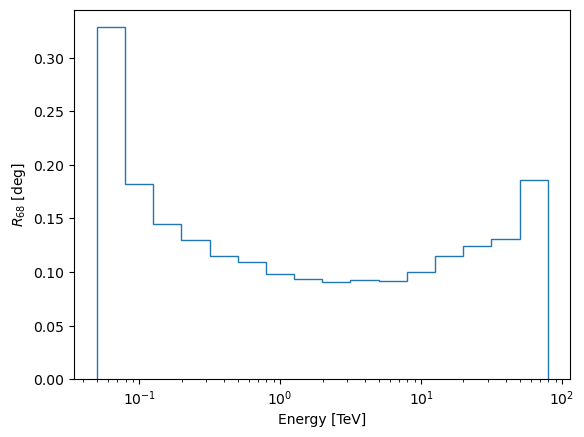

In [11]:
pyplot.semilogx()
pyplot.xlabel('Energy [TeV]')
pyplot.ylabel('$R_{68}$ [deg]')
pyplot.stairs(
    r68,
    energy_edges
)